In [ ]:
#Generate dataset
import sys
import os
import numpy as np
sys.path.append(os.path.abspath('..')) 

num_individuals = 2
num_timepoints = 100
all_data = []
all_true_cps = []   # True change points (optional, for validation)

def generate_synthetic_data_2node_multicps(num_time_points=100, epsilon=0.5, snr=50):
    """Modified: 2-node network (X → X and X → Y) with 5 change points"""
    np.random.seed(42)
    m = num_time_points
    X = np.zeros(m)
    Y = np.zeros(m)
    phi_X = np.random.normal(0, 1, m)
    phi_Y = np.random.normal(0, 1, m)

    X[0] = np.random.normal(0, 1)
    beta = np.ones(m)

    # Define 5 equal segments
    segment_edges = np.linspace(0, m, 6, dtype=int)  # 6 points = 5 segments
    change_points = segment_edges[1:-1]  # inner edges are the CPs

    # Assign different beta values to each segment
    beta[segment_edges[0]:segment_edges[1]] = 1
    beta[segment_edges[1]:segment_edges[2]] = -2
    beta[segment_edges[2]:segment_edges[3]] = 0
    beta[segment_edges[3]:segment_edges[4]] = -2
    beta[segment_edges[4]:segment_edges[5]] = 1

    # Generate X (autoregressive)
    for t in range(1, m):
        X[t] = np.sqrt(1 - epsilon ** 2) * X[t - 1] + epsilon * phi_X[t]

    # Scale noise
    sigma_beta_X = np.std(beta * X)
    c = sigma_beta_X / snr

    # Generate Y (influenced by beta * X + noise)
    for t in range(m - 1):
        Y[t + 1] = beta[t] * X[t] + c * phi_Y[t + 1]

    data = np.vstack([X, Y])
    true_cps = [change_points.tolist(), change_points.tolist()]  # CPs for both X and Y
    return data, true_cps

for i in range(num_individuals):
    data_i, true_cps_i = generate_synthetic_data_2node_multicps(num_timepoints)
    all_data.append(data_i)
    all_true_cps.append(true_cps_i)

node_names = ["X", "Y"]

[array([[ 3.57787360e-01,  2.40720793e-01,  5.32314591e-01,
         1.22251289e+00,  9.41650529e-01,  6.98424801e-01,
         1.39446003e+00,  1.59135517e+00,  1.14341681e+00,
         1.26150803e+00,  8.60789154e-01,  5.12600398e-01,
         5.64906103e-01, -4.67417087e-01, -1.26725399e+00,
        -1.37861791e+00, -1.70033369e+00, -1.31540851e+00,
        -1.59318922e+00, -2.08589419e+00, -1.07361297e+00,
        -1.04266426e+00, -8.69209633e-01, -1.46513172e+00,
        -1.54103265e+00, -1.27911213e+00, -1.68324039e+00,
        -1.26987992e+00, -1.40006762e+00, -1.35834100e+00,
        -1.47721112e+00, -3.53163264e-01, -3.12596971e-01,
        -7.99572382e-01, -2.81177539e-01, -8.53928717e-01,
        -6.35092164e-01, -1.52984101e+00, -1.98897420e+00,
        -1.62407157e+00, -1.03725395e+00, -8.12604127e-01,
        -7.61559959e-01, -8.10082118e-01, -1.44081269e+00,
        -1.60770249e+00, -1.62263059e+00, -8.76678197e-01,
        -5.87416445e-01, -1.39023764e+00, -1.04193913e+

In [ ]:
#Find change points
# This script performs MCMC inference on synthetic data, identifies change points,
# and splits the data into segments based on these change points.
from cpbge.mcmc import MCMC
from cpbge.plotting import plot_time_series_with_changepoints
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Generate synthetic time series data with known structure
# X[t] depends on X[t−1], Y[t] depends on X[t-1] + noise
def generate_synthetic_data_2node(num_time_points=100, epsilon=0.5, snr=50):
    np.random.seed(42)
    m = num_time_points
    X = np.zeros(m)
    Y = np.zeros(m)
    phi_X = np.random.normal(0, 1, m)
    phi_Y = np.random.normal(0, 1, m)

    # Set beta with changepoints
    beta = np.ones(m)
    third = m // 3
    beta[third:(2 * third)] = -1

    # Generate X as autoregressive
    X[0] = np.random.normal(0, 1)
    for t in range(1, m):
        X[t] = np.sqrt(1 - epsilon**2) * X[t - 1] + epsilon * phi_X[t]

    # Compute noise scale for Y based on SNR
    sigma_beta_X = np.std(beta * X)
    c = sigma_beta_X / snr

    # Generate Y with a lagged dependence on X and noise
    for t in range(m - 1):
        Y[t + 1] = beta[t] * X[t] + c * phi_Y[t + 1]

    return np.vstack([X, Y]), [[third, 2 * third], [third, 2 * third]]

# Discretize continuous time series data into bins
def discretize_segment_data(segment_data, num_bins=3):
    binned_data = np.zeros_like(segment_data, dtype=int)
    bin_edges = []
    bin_probs = []

    for i in range(segment_data.shape[0]):
        bins = np.histogram_bin_edges(segment_data[i], bins=num_bins)
        binned = np.digitize(segment_data[i], bins=bins[:-1], right=False) - 1
        counts = np.bincount(binned, minlength=num_bins)
        probs = counts / counts.sum()

        binned_data[i] = binned
        bin_edges.append(bins)
        bin_probs.append(probs)

    return binned_data, bin_edges, bin_probs

# Estimate conditional probability table: P(child[t] | parent[t−1])
def estimate_cpt(parent, child, num_bins):
    cpt = np.zeros((num_bins, num_bins))
    for t in range(1, len(parent)):
        p = parent[t - 1]
        c = child[t]
        cpt[p, c] += 1

    with np.errstate(invalid='ignore'):
        cpt = cpt / cpt.sum(axis=1, keepdims=True)

    return np.nan_to_num(cpt)

def print_learned_structure(edge_probs, mean_K, allocation, node_names=None):
    """Prints edges and change points using readable node labels."""
    if node_names is None:
        node_names = [str(i) for i in range(len(mean_K))]

    print("Learned Edge Probabilities (edges with prob > 0.5):")
    for (u, v), prob in edge_probs.items():
        if prob > 0.5:
            print(f"  Edge {node_names[u]} → {node_names[v]}: {prob:.3f}")

    print("Changepoints")
    for node in range(allocation.shape[0]):
        cps = np.where(allocation[node, 1:] != allocation[node, :-1])[0]
        print(f"  Node {node_names[node]}: {cps.tolist()} (K = {len(cps)+1})")
    return cps

def plot_2node_discretized_with_changepoints():
    plt.figure(figsize=(12, 4))
    plt.plot(binned_full[0], label='X', marker='o')
    plt.plot(binned_full[1], label='Y', marker='x')
    for cp in changepoints[0]:
        plt.axvline(x=cp, color='red', linestyle='--', label='Changepoint' if cp == changepoints[0][0] else "")
    plt.title('Discretized Time Series from Continuous Data')
    plt.xlabel('Time')
    plt.ylabel('Category')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# MAIN
all_edge_probs = [[]]
all_allocations = [[]]
all_K = [[]]
all_cps = [[]]
num_bins = 19

for indiv in range(len(all_data)):
    
    model = MCMC(num_nodes=all_data[indiv].shape[0], max_segments=10)
    edge_probs, mean_K, allocation, samples = model.mcmc_inference(
        all_data[i], num_iterations=500000, burn_in=1000
    )
    
    pred_cps = print_learned_structure(edge_probs, mean_K, allocation, node_names=node_names)
    
    all_edge_probs[indiv].append(edge_probs)
    all_allocations[indiv].append(allocation)
    all_K[indiv].append(mean_K)
    all_cps[indiv].append(pred_cps)
    


segments = [0] + pred_cps[0] + [data.shape[1]]

    for i in range(len(segments) - 1):
        start, end = segments[i], segments[i + 1]
        segment_data = data[:, start:end]

        # Discretize the segment
        binned_data, bin_edges, bin_probs = discretize_segment_data(segment_data, num_bins)

        # Estimate CPTs: P(X[t] | X[t−1]) and P(Y[t] | X[t−1])
        cpt_X = estimate_cpt(binned_data[0], binned_data[0], num_bins)
        cpt_Y = estimate_cpt(binned_data[0], binned_data[1], num_bins)

        # Print results
        print(f"\n=== Segment {i + 1}: Time [{start}, {end}) ===")
        print("Bins for X:", bin_edges[0])
        print("Bins for Y:", bin_edges[1])
        #print("P(X[t] | X[t−1]) CPT:")
        col_labels = [f"X={k}" for k in range(num_bins)]
        idx_labels = [f"X_prev={k}" for k in range(num_bins)]
        #print(pd.DataFrame(cpt_X, columns=col_labels, index=idx_labels))

        #print("\nP(Y[t] | X[t−1]) CPT:")
        col_labels_y = [f"Y={k}" for k in range(num_bins)]
        #print(pd.DataFrame(cpt_Y, columns=col_labels_y, index=idx_labels))


    # Plot the globally discretized X and Y series with changepoints
    binned_full = np.zeros_like(data, dtype=int)
    for i in range(data.shape[0]):
        bins = np.histogram_bin_edges(data[i], bins=num_bins)
        binned_full[i] = np.digitize(data[i], bins=bins[:-1], right=False) - 1

plot_2node_discretized_with_changepoints()



  0%|          | 0/2 [00:00<?, ?it/s]


=== Individual 1 ===
Learned Edge Probabilities (edges with prob > 0.5):
  Edge X → X: 1.000
  Edge X → Y: 1.000
  Edge Y → Y: 1.000
Changepoints
  Node X: [] (K = 1)
  Node Y: [20, 79] (K = 3)
Learned Change Points: [array([20, 79]), array([20, 79])]


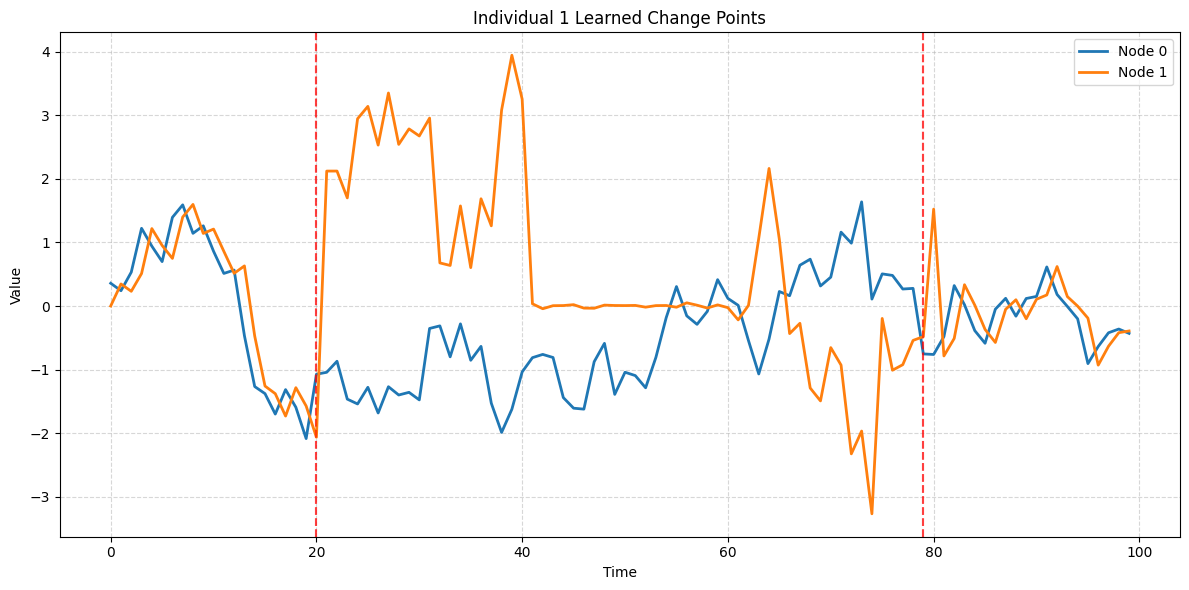

 50%|█████     | 1/2 [01:44<01:44, 104.12s/it]


=== Individual 2 ===
Learned Edge Probabilities (edges with prob > 0.5):
  Edge X → X: 1.000
  Edge X → Y: 1.000
Changepoints
  Node X: [] (K = 1)
  Node Y: [20, 38, 80] (K = 4)
Learned Change Points: [array([20, 38, 80]), array([20, 38, 80])]


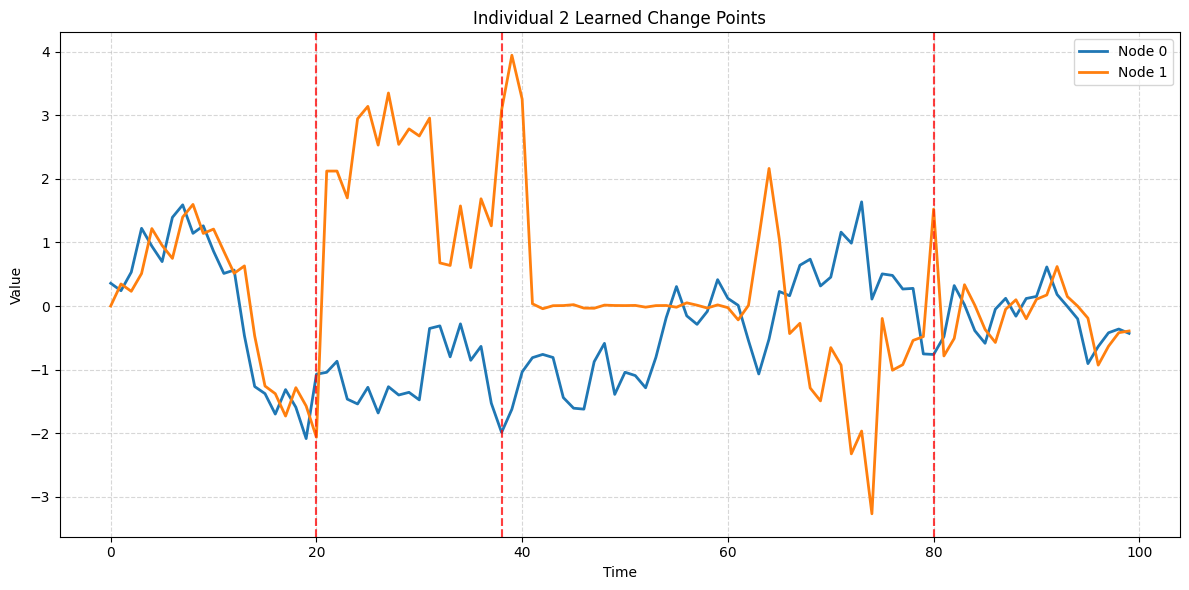

100%|██████████| 2/2 [03:40<00:00, 110.34s/it]


In [10]:
from tqdm import tqdm
from cpbge.mcmc import MCMC
from cpbge.plotting import plot_time_series_with_changepoints

def print_learned_structure(edge_probs, mean_K, allocation, node_names=None):
    """Prints edges and change points using readable node labels."""
    if node_names is None:
        node_names = [str(i) for i in range(len(mean_K))]

    print("Learned Edge Probabilities (edges with prob > 0.5):")
    for (u, v), prob in edge_probs.items():
        if prob > 0.5:
            print(f"  Edge {node_names[u]} → {node_names[v]}: {prob:.3f}")

    print("Changepoints")
    for node in range(allocation.shape[0]):
        cps = np.where(allocation[node, 1:] != allocation[node, :-1])[0]
        print(f"  Node {node_names[node]}: {cps.tolist()} (K = {len(cps)+1})")
    return cps


all_edge_probs = []
all_allocations = []
all_K = []
all_cps = []
i = 1

for data_i in tqdm(all_data):
    print(f"\n=== Individual {i} ===")
    
    model = MCMC(num_nodes=data_i.shape[0], max_segments=10)
    edge_probs, mean_K, allocation, samples = model.mcmc_inference(
        data_i, num_iterations=500000, burn_in=1000
    )

    cps_per_node = print_learned_structure(edge_probs, mean_K, allocation, node_names=node_names)
    cps_per_node = [cps_per_node] * len(node_names)
    print("Learned Change Points:", cps_per_node)
    # Collect outputs
    all_edge_probs.append(edge_probs)
    all_allocations.append(allocation)
    all_K.append(mean_K)
    all_cps.append(cps_per_node)

    plot_time_series_with_changepoints(data_i, cps_per_node, title=f"Individual {i} Learned Change Points")
    i+=1


In [16]:
# Discretize continuous time series data into bins
def discretize_segment_data(segment_data, num_bins=3):
    binned_data = np.zeros_like(segment_data, dtype=int)
    bin_edges = []
    bin_probs = []

    for i in range(segment_data.shape[0]):
        bins = np.histogram_bin_edges(segment_data[i], bins=num_bins)
        binned = np.digitize(segment_data[i], bins=bins[:-1], right=False) - 1
        counts = np.bincount(binned, minlength=num_bins)
        probs = counts / counts.sum()

        binned_data[i] = binned
        bin_edges.append(bins)
        bin_probs.append(probs)

    return binned_data, bin_edges, bin_probs

# Estimate conditional probability table: P(child[t] | parent[t−1])
def estimate_cpt(parent, child, num_bins):
    cpt = np.zeros((num_bins, num_bins))
    for t in range(1, len(parent)):
        p = parent[t - 1]
        c = child[t]
        cpt[p, c] += 1

    with np.errstate(invalid='ignore'):
        cpt = cpt / cpt.sum(axis=1, keepdims=True)

    return np.nan_to_num(cpt)


num_bins = 3

for idx in tqdm(range(len(all_data))):
    data_i = all_data[idx]
    print(data_i)
    cps = all_cps[idx]
    print(cps[0])
    segments = [0] + cps[0] + [data_i.shape[1]]
    for i in range(len(segments) - 1):
        start, end = segments[i], segments[i + 1]
        segment_data = data_i[:, start:end]

        # Discretize the segment
        binned_data, bin_edges, bin_probs = discretize_segment_data(segment_data, num_bins)

        # Estimate CPTs: P(X[t] | X[t−1]) and P(Y[t] | X[t−1])
        cpt_X = estimate_cpt(binned_data[0], binned_data[0], num_bins)
        cpt_Y = estimate_cpt(binned_data[0], binned_data[1], num_bins)

        # Print results
        print(f"\n=== Segment {i + 1}: Time [{start}, {end}) ===")
        print("Bins for X:", bin_edges[0])
        print("Bins for Y:", bin_edges[1])
        print("P(X[t] | X[t−1]) CPT:")
        col_labels = [f"X={k}" for k in range(num_bins)]
        idx_labels = [f"X_prev={k}" for k in range(num_bins)]
        print(pd.DataFrame(cpt_X, columns=col_labels, index=idx_labels))

        #print("\nP(Y[t] | X[t−1]) CPT:")
        col_labels_y = [f"Y={k}" for k in range(num_bins)]
        #print(pd.DataFrame(cpt_Y, columns=col_labels_y, index=idx_labels))


    # Plot the globally discretized X and Y series with changepoints
    binned_full = np.zeros_like(data_i, dtype=int)
    for i in range(data_i.shape[0]):
        bins = np.histogram_bin_edges(data_i[i], bins=num_bins)
        binned_full[i] = np.digitize(data_i[i], bins=bins[:-1], right=False) - 1


  0%|          | 0/2 [00:00<?, ?it/s]/var/folders/_h/mf70q7412jb3711dk_rzmys40000gp/T/ipykernel_6651/2232881414.py:11: RuntimeWarning: invalid value encountered in divide
  probs = counts / counts.sum()
  0%|          | 0/2 [00:00<?, ?it/s]

[[ 3.57787360e-01  2.40720793e-01  5.32314591e-01  1.22251289e+00
   9.41650529e-01  6.98424801e-01  1.39446003e+00  1.59135517e+00
   1.14341681e+00  1.26150803e+00  8.60789154e-01  5.12600398e-01
   5.64906103e-01 -4.67417087e-01 -1.26725399e+00 -1.37861791e+00
  -1.70033369e+00 -1.31540851e+00 -1.59318922e+00 -2.08589419e+00
  -1.07361297e+00 -1.04266426e+00 -8.69209633e-01 -1.46513172e+00
  -1.54103265e+00 -1.27911213e+00 -1.68324039e+00 -1.26987992e+00
  -1.40006762e+00 -1.35834100e+00 -1.47721112e+00 -3.53163264e-01
  -3.12596971e-01 -7.99572382e-01 -2.81177539e-01 -8.53928717e-01
  -6.35092164e-01 -1.52984101e+00 -1.98897420e+00 -1.62407157e+00
  -1.03725395e+00 -8.12604127e-01 -7.61559959e-01 -8.10082118e-01
  -1.44081269e+00 -1.60770249e+00 -1.62263059e+00 -8.76678197e-01
  -5.87416445e-01 -1.39023764e+00 -1.04193913e+00 -1.09488690e+00
  -1.28666087e+00 -8.08442852e-01 -1.84632286e-01  3.05743810e-01
  -1.54826856e-01 -2.88690178e-01 -8.43813123e-02  4.14696204e-01
   1.19550

NameError: name 'pd' is not defined